# 🔍 Détection de Fraudes Fournisseurs — Isolation Forest

**Objectif** : Entraîner un modèle non-supervisé (Isolation Forest) pour détecter des comportements anormaux dans les transactions fournisseurs, en **complément** des règles métier déjà construites.

**Données disponibles** :
- `transactions_scorees.csv` — toutes les transactions + scoring des règles
- `fournisseurs_clean.csv` — données fournisseurs
- `employes_clean.csv` — données employés
- `profil_montant_fournisseur.csv` — statistiques de montants par fournisseur
- `journal_fraudes_injectees.csv` — 116 cas de fraude (vérité terrain, uniquement pour évaluation)

---

## Étape 1 — Chargement et exploration initiale des données

In [1]:
import pandas as pd
import numpy as np
import os

# ── Chemins ──────────────────────────────────────────────────────────────────
BASE = "/Users/louayzorai/Desktop/4 ARTIC 6/LOUAY/Stage EY/DATA"
OUT  = os.path.join(BASE, "output_clean")
RAW  = os.path.join(BASE, "data", "raw")

# ── Chargement ───────────────────────────────────────────────────────────────
df_tx       = pd.read_csv(os.path.join(OUT, "transactions_scorees.csv"))
df_frs      = pd.read_csv(os.path.join(OUT, "fournisseurs_clean.csv"))
df_emp      = pd.read_csv(os.path.join(OUT, "employes_clean.csv"))
df_profil   = pd.read_csv(os.path.join(OUT, "profil_montant_fournisseur.csv"))
df_journal  = pd.read_csv(os.path.join(RAW, "journal_fraudes_injectees.csv"), encoding="utf-8-sig")

print("✅ Fichiers chargés avec succès")

✅ Fichiers chargés avec succès


In [2]:
# ── Dimensions de chaque fichier ───────────────────────────────────────────────────
files = {
    "transactions_scorees": df_tx,
    "fournisseurs_clean":    df_frs,
    "employes_clean":        df_emp,
    "profil_montant_fournisseur": df_profil,
    "journal_fraudes_injectees": df_journal,
}

print(f"{'Fichier':<35} {'Lignes':>8} {'Colonnes':>10}")
print("-" * 56)
for name, df in files.items():
    print(f"{name:<35} {df.shape[0]:>8,} {df.shape[1]:>10}")

Fichier                               Lignes   Colonnes
--------------------------------------------------------
transactions_scorees                  78,020         17
fournisseurs_clean                       164         11
employes_clean                            37          6
profil_montant_fournisseur               163          4
journal_fraudes_injectees                124          2


### 1.1 — Premières lignes des fichiers principaux

In [3]:
# Apercu transactions_scorees (fichier principal)
print("=== transactions_scorees ===")
display(df_tx.head(3))

print("\n=== fournisseurs_clean ===")
display(df_frs.head(3))

print("\n=== profil_montant_fournisseur ===")
display(df_profil.head(3))

print("\n=== journal_fraudes_injectees ===")
display(df_journal.head(10))

=== transactions_scorees ===


,id_transaction,date_transaction,id_fournisseur,montant,devise,type_depense,mode_paiement,id_employe_initiateur,id_employe_validateur,statut_validation,numero_facture,regle_rib_partage,regle_montant_anormal,regle_doublon_facture,regle_creation_tardive,score_risque,niveau_risque
0,TX-0002914,2024-09-06,FRS-00067,3321.042,TND,Prestation technique,Virement,EMP-025,EMP-006,Validé,FAC-79603,False,False,False,False,0,Faible
1,TX-0001741,2024-09-06,FRS-00108,237.281,TND,Location matériel,Virement,EMP-006,EMP-006,En attente,FAC-95678,False,False,False,False,0,Faible
2,TX-0000849,2024-09-06,FRS-00144,605.361,TND,Maintenance,Virement,EMP-002,EMP-016,Validé,FAC-47409,False,False,False,False,0,Faible



=== fournisseurs_clean ===


,id_fournisseur,nom_fournisseur,rib_iban,adresse,telephone,date_creation_fournisseur,statut_fournisseur,pays,rib_iban_normalise,nom_normalise,fournisseur_a_risque
0,FRS-00001,Electro Plus,TN59 0318 6265 9693 9007 9389,"109 Avenue Habib Bourguiba, Ariana",+216 23 270 516,2024-08-11,Actif,Tunisie,TN5903186265969390079389,electro plus,False
1,FRS-00002,Tunisie Composants,TN59 8963 2247 2991 6803 3060,"117 Avenue Habib Bourguiba, Sfax",+216 26 102 499,2024-08-02,Actif,Tunisie,TN5989632247299168033060,tunisie composants,False
2,FRS-00003,Maghreb Electronics,TN59 7853 7787 6051 7878 1459,"38 Avenue Taïeb Mhiri, Gafsa",+216 28 777 835,2024-08-06,Actif,Tunisie,TN5978537787605178781459,maghreb electronics,False



=== profil_montant_fournisseur ===


,id_fournisseur,montant_moyen,montant_ecart_type,nb_transactions
0,FRS-00001,251.394539,63.085678,545
1,FRS-00002,500.789555,124.478428,578
2,FRS-00003,797.171359,208.578444,579



=== journal_fraudes_injectees ===


,type_fraude,reference
0,RIB partagé,FRS-00120/FRS-00065
1,Montant anormal,TX-0062283
2,Doublon de facture,TX-0044113
3,Création fournisseur juste avant paiement,FRS-00111
4,RIB partagé,FRS-00149/FRS-00123
5,Montant anormal,TX-0025113
6,Doublon de facture,TX-0017190
7,Création fournisseur juste avant paiement,FRS-00145
8,RIB partagé,FRS-00142/FRS-00041
9,Montant anormal,TX-0053260


### 1.2 — Types de colonnes et valeurs manquantes

In [4]:
def explore(df, name):
    """Résumé rapide : types, valeurs manquantes, % nulls."""
    summary = pd.DataFrame({
        "dtype":       df.dtypes,
        "non_null":    df.notna().sum(),
        "null_count":  df.isna().sum(),
        "null_pct":    (df.isna().mean() * 100).round(2),
        "n_unique":    df.nunique(),
    })
    print(f"\n{'='*60}")
    print(f"  {name}  ({df.shape[0]:,} lignes x {df.shape[1]} colonnes)")
    print(f"{'='*60}")
    display(summary)

for name, df in files.items():
    explore(df, name)


  transactions_scorees  (78,020 lignes x 17 colonnes)


,dtype,non_null,null_count,null_pct,n_unique
id_transaction,str,78020,0,0.0,77901
date_transaction,str,78020,0,0.0,705
id_fournisseur,str,78020,0,0.0,163
montant,float64,78020,0,0.0,77003
devise,str,78020,0,0.0,1
type_depense,str,78020,0,0.0,7
mode_paiement,str,78020,0,0.0,2
id_employe_initiateur,str,78020,0,0.0,25
id_employe_validateur,str,78020,0,0.0,21
statut_validation,str,78020,0,0.0,3



  fournisseurs_clean  (164 lignes x 11 colonnes)


,dtype,non_null,null_count,null_pct,n_unique
id_fournisseur,str,164,0,0.0,164
nom_fournisseur,str,164,0,0.0,164
rib_iban,str,164,0,0.0,145
adresse,str,164,0,0.0,135
telephone,str,164,0,0.0,164
date_creation_fournisseur,str,164,0,0.0,69
statut_fournisseur,str,164,0,0.0,3
pays,str,164,0,0.0,7
rib_iban_normalise,str,164,0,0.0,145
nom_normalise,str,164,0,0.0,164



  employes_clean  (37 lignes x 6 colonnes)


,dtype,non_null,null_count,null_pct,n_unique
id_employe,str,37,0,0.0,37
nom_employe,str,37,0,0.0,37
poste,str,37,0,0.0,7
adresse_personnelle,str,37,0,0.0,34
telephone,str,37,0,0.0,37
date_embauche,str,37,0,0.0,35



  profil_montant_fournisseur  (163 lignes x 4 colonnes)


,dtype,non_null,null_count,null_pct,n_unique
id_fournisseur,str,163,0,0.0,163
montant_moyen,float64,163,0,0.0,163
montant_ecart_type,float64,163,0,0.0,163
nb_transactions,int64,163,0,0.0,98



  journal_fraudes_injectees  (124 lignes x 2 colonnes)


,dtype,non_null,null_count,null_pct,n_unique
type_fraude,str,124,0,0.0,10
reference,str,124,0,0.0,124


### 1.3 — Statistiques descriptives du fichier transactions_scorees

In [5]:
# Stats descriptives des colonnes numériques (montant + profil)
print("=== transactions_scorees - colonnes numériques ===")
display(df_tx.describe())

print("\n=== profil_montant_fournisseur ===")
display(df_profil.describe())

# Répartition des niveaux de risque déjà calculés
print("\n=== Répartition niveau_risque (règles existantes) ===")
print(df_tx["niveau_risque"].value_counts())

# Contenu du journal de fraude
print("\n=== Types de fraude injectés ===")
print(df_journal["type_fraude"].value_counts())
print(f"\nTotal lignes journal : {len(df_journal)}")
print(f"Dont 'Multi-signaux' : {df_journal['type_fraude'].str.startswith('Multi').sum()}")

=== transactions_scorees - colonnes numériques ===


,montant,score_risque
count,78020.000000,78020.000000
mean,2554.035605,0.003473
std,2985.397430,0.058834
min,50.000000,0.000000
25%,520.383500,0.000000
50%,1202.916000,0.000000
75%,3449.423500,0.000000
max,44311.184000,1.000000



=== profil_montant_fournisseur ===


,montant_moyen,montant_ecart_type,nb_transactions
count,163.000000,163.000000,163.000000
mean,2519.667358,634.795393,478.650307
std,2755.104862,716.195922,176.547672
min,247.590600,57.094807,9.000000
25%,531.583555,131.151556,521.000000
50%,1495.054996,229.106727,553.000000
75%,3024.434614,776.858259,571.500000
max,9186.860043,2397.252959,609.000000



=== Répartition niveau_risque (règles existantes) ===
niveau_risque
Faible    78020
Name: count, dtype: int64

=== Types de fraude injectés ===
type_fraude
Doublon de facture                           21
RIB partagé                                  20
Montant anormal                              20
Création fournisseur juste avant paiement    20
Multi-signaux - Concentration employé        10
Multi-signaux - Montant+timing                9
Multi-signaux - Dérive progressive            8
Multi-signaux - Fréquence post-création       8
Collusion - directe                           5
Collusion - indirecte                         3
Name: count, dtype: int64

Total lignes journal : 124
Dont 'Multi-signaux' : 35


---

## Étape 2 — Feature Engineering

> **Principe anti-fuite** : toutes les features sont construites **uniquement** à partir des données brutes/nettoyées.  
> Les colonnes de règles (`regle_*`), de score (`score_risque`, `niveau_risque`) et toute information du journal de fraude sont **strictement exclues** du tableau de features final.

### Features construites
| Feature | Source | Intention |
|---|---|---|
| `ecart_montant_normalise` | `profil_montant_fournisseur` | Détecter un montant anormalement élevé/faible par rapport au profil historique du fournisseur |
| `delai_depuis_creation` | `fournisseurs_clean` | Repérer les transactions très rapides après la création du fournisseur |
| `ratio_concentration_employe` | `transactions_clean` | Identifier une collusion entre un même binôme initiateur/validateur sur un fournisseur donné |
| `rang_temporel_fournisseur` | `transactions_clean` | Capturer la position de la transaction dans l'historique du fournisseur (dérive progressive) |
| `jour_semaine` | `transactions_clean` | Détecter des patterns weekend/semaine inhabituels |
| `jour_du_mois` | `transactions_clean` | Détecter des patterns de fin de mois suspects |
| `frequence_7j_fournisseur` | `transactions_clean` | Mesurer l'intensité des transactions sur les 7 jours précédant la transaction (fréquence post-création) |
| `montant_log` | `transactions_clean` | Réduire l'asymétrie de la distribution des montants pour Isolation Forest |
| `nb_tx_fournisseur` | `profil_montant_fournisseur` | Volume total de transactions du fournisseur — les fournisseurs peu actifs sont plus suspects |
| `auto_validation` | `transactions_clean` | Détecte si l'initiateur est aussi le validateur (absence de séparation des tâches) |

### 2.1 — Préparation de la base de travail

On part de `transactions_scorees.csv` (qui contient toutes les transactions avec les colonnes de règles), mais on **élimine immédiatement** les colonnes à exclure avant toute jointure, pour éviter la moindre fuite.

In [6]:
# ── 2.1 Base de travail : colonnes brutes uniquement ─────────────────────────
# Colonnes de règles/scores à bannir (data leakage)
COLS_EXCLUES = [
    "regle_rib_partage", "regle_montant_anormal",
    "regle_doublon_facture", "regle_creation_tardive",
    "score_risque", "niveau_risque",
]

# Base de travail = transactions_scorees SANS les colonnes à exclure
df = df_tx.drop(columns=COLS_EXCLUES).copy()

# Conversions de dates
df["date_transaction"] = pd.to_datetime(df["date_transaction"])

# Conversion dates fournisseurs
df_frs_dates = df_frs[["id_fournisseur", "date_creation_fournisseur"]].copy()
df_frs_dates["date_creation_fournisseur"] = pd.to_datetime(df_frs_dates["date_creation_fournisseur"])

print(f"✅ Base de travail : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"   Colonnes restantes : {list(df.columns)}")
print(f"\n🔒 Colonnes exclues (anti-leakage) : {COLS_EXCLUES}")

✅ Base de travail : 78,020 lignes x 11 colonnes
   Colonnes restantes : ['id_transaction', 'date_transaction', 'id_fournisseur', 'montant', 'devise', 'type_depense', 'mode_paiement', 'id_employe_initiateur', 'id_employe_validateur', 'statut_validation', 'numero_facture']

🔒 Colonnes exclues (anti-leakage) : ['regle_rib_partage', 'regle_montant_anormal', 'regle_doublon_facture', 'regle_creation_tardive', 'score_risque', 'niveau_risque']


### 2.2 — Construction des features demandées + features complémentaires

In [7]:
# ─────────────────────────────────────────────────────────────────────────
# FEATURE 1 : ecart_montant_normalise
# = (montant - montant_moyen_fournisseur) / montant_ecart_type_fournisseur
# Capte les montants deviants du profil historique du fournisseur.
# Gestion division par zero : si ecart_type == 0 -> ecart force a 0
#   (le montant est identique a tous les autres, donc non anormal).
# ─────────────────────────────────────────────────────────────────────────
df = df.merge(df_profil[["id_fournisseur", "montant_moyen", "montant_ecart_type", "nb_transactions"]],
              on="id_fournisseur", how="left")

# Division securisee : ecart_type = 0 -> z-score = 0 (pas d'anomalie possible)
df["ecart_montant_normalise"] = np.where(
    df["montant_ecart_type"].fillna(0) == 0,
    0.0,
    (df["montant"] - df["montant_moyen"]) / df["montant_ecart_type"]
)

print("✅ Feature 1 : ecart_montant_normalise")
print(f"   Fournisseurs sans ecart_type (std=0) : {(df['montant_ecart_type'] == 0).sum()}")
print(f"   Jointures non-matchees (NaN montant_moyen) : {df['montant_moyen'].isna().sum()}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 2 : delai_depuis_creation
# = nombre de jours entre date_creation_fournisseur et date_transaction.
# Un delai tres court (0-7 jours) est un signal fort de fraude.
# ─────────────────────────────────────────────────────────────────────────
df = df.merge(df_frs_dates, on="id_fournisseur", how="left")

df["delai_depuis_creation"] = (
    df["date_transaction"] - df["date_creation_fournisseur"]
).dt.days

# Clamp : valeur negative impossible en pratique, mais securite
df["delai_depuis_creation"] = df["delai_depuis_creation"].clip(lower=0)

print("\n✅ Feature 2 : delai_depuis_creation")
print(f"   Min / Median / Max : {df['delai_depuis_creation'].min():.0f} / "
      f"{df['delai_depuis_creation'].median():.0f} / {df['delai_depuis_creation'].max():.0f} jours")
print(f"   Transactions avec delai < 7j : {(df['delai_depuis_creation'] < 7).sum():,}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 3 : ratio_concentration_employe
# Pour chaque transaction (fournisseur F, binome B = initiateur+validateur) :
# proportion des transactions de F traitees par ce meme binome B.
# Un ratio eleve signale une concentration anormale = risque de collusion.
# ─────────────────────────────────────────────────────────────────────────
nb_tx_par_frs = df.groupby("id_fournisseur")["id_transaction"].transform("count")
nb_tx_binome  = df.groupby(
    ["id_fournisseur", "id_employe_initiateur", "id_employe_validateur"]
)["id_transaction"].transform("count")

df["ratio_concentration_employe"] = nb_tx_binome / nb_tx_par_frs

print("\n✅ Feature 3 : ratio_concentration_employe")
print(f"   Min / Med / Max : {df['ratio_concentration_employe'].min():.4f} / "
      f"{df['ratio_concentration_employe'].median():.4f} / {df['ratio_concentration_employe'].max():.4f}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 4 : rang_temporel_fournisseur
# Rang (chrono) de la transaction pour ce fournisseur, normalise entre 0 et 1.
# rang / n_total : proche de 0 = debut de vie du fournisseur (derive progressive).
# ─────────────────────────────────────────────────────────────────────────
df = df.sort_values(["id_fournisseur", "date_transaction"]).copy()

df["rang_brut"] = df.groupby("id_fournisseur")["date_transaction"].rank(method="min")
nb_tx_frs     = df.groupby("id_fournisseur")["id_transaction"].transform("count")

df["rang_temporel_fournisseur"] = df["rang_brut"] / nb_tx_frs
df.drop(columns=["rang_brut"], inplace=True)

print("\n✅ Feature 4 : rang_temporel_fournisseur")
print(f"   Min / Max : {df['rang_temporel_fournisseur'].min():.4f} / {df['rang_temporel_fournisseur'].max():.4f}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 5 : jour_semaine + jour_du_mois
# 0=Lundi...6=Dimanche ; 1-31
# Captures les patterns temporels : weekends suspects, fins de mois.
# ─────────────────────────────────────────────────────────────────────────
df["jour_semaine"] = df["date_transaction"].dt.dayofweek
df["jour_du_mois"] = df["date_transaction"].dt.day

print("\n✅ Features 5 : jour_semaine + jour_du_mois")
print(f"   jour_semaine unique : {sorted(df['jour_semaine'].unique())}")
print(f"   jour_du_mois : min={df['jour_du_mois'].min()}, max={df['jour_du_mois'].max()}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 6 (complementaire) : frequence_7j_fournisseur
# Nombre de transactions du meme fournisseur dans les 7 jours AVANT la tx.
# Une explosion soudaine de frequence apres creation = signal
# "Frequence post-creation" (multi-signaux).
# Implementation : on indexe le DataFrame par date_transaction pour
# utiliser rolling avec une fenetre temporelle '7D', par groupe fournisseur.
# ─────────────────────────────────────────────────────────────────────────

def _count_rolling_7d(group: pd.DataFrame) -> pd.Series:
    """Compter les tx du meme fournisseur dans les 7 jours precedents.
    Le DataFrame de groupe doit etre trie par date_transaction.
    """
    # Indexer par date pour que rolling('7D') soit interpretatble
    indexed = group.set_index("date_transaction")["id_transaction"]
    counts  = indexed.rolling("7D").count().astype(int) - 1  # -1 : exclure la tx courante
    # Remettre l'index original (row index du df principal)
    counts.index = group.index
    return counts

# Sous-tableau minimaliste trie par (fournisseur, date)
df_sub = (
    df[["id_transaction", "id_fournisseur", "date_transaction"]]
    .sort_values(["id_fournisseur", "date_transaction"])
)

freq_series = (
    df_sub
    .groupby("id_fournisseur", group_keys=False)
    .apply(_count_rolling_7d)
)

# La serie a le meme index que df_sub -> on merge proprement
df_sub = df_sub.copy()
df_sub["frequence_7j_fournisseur"] = freq_series.values

df = df.merge(
    df_sub[["id_transaction", "frequence_7j_fournisseur"]],
    on="id_transaction", how="left"
)

print("\n✅ Feature 6 : frequence_7j_fournisseur")
print(f"   Min / Median / Max : {df['frequence_7j_fournisseur'].min():.0f} / "
      f"{df['frequence_7j_fournisseur'].median():.0f} / {df['frequence_7j_fournisseur'].max():.0f}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 7 (complementaire) : montant_log
# log(1 + montant) pour reduire l'asymetrie : Isolation Forest est
# sensible aux distributions a longue queue.
# ─────────────────────────────────────────────────────────────────────────
df["montant_log"] = np.log1p(df["montant"])

print("\n✅ Feature 7 : montant_log")
print(f"   Min / Max brut : {df['montant'].min():.2f} / {df['montant'].max():.2f}")
print(f"   Min / Max log  : {df['montant_log'].min():.4f} / {df['montant_log'].max():.4f}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 8 (complementaire) : nb_tx_fournisseur
# Volume total de transactions du fournisseur (depuis profil_montant_fournisseur).
# Un petit volume = fournisseur peu actif = plus facile a manipuler.
# ─────────────────────────────────────────────────────────────────────────
df["nb_tx_fournisseur"] = df["nb_transactions"]

print("\n✅ Feature 8 : nb_tx_fournisseur")
print(f"   Min / Max : {df['nb_tx_fournisseur'].min():.0f} / {df['nb_tx_fournisseur'].max():.0f}")

# ─────────────────────────────────────────────────────────────────────────
# FEATURE 9 (complementaire) : auto_validation
# 1 si l'initiateur = le validateur (absence de separation des taches).
# Signal fort de collusion / fraude interne.
# ─────────────────────────────────────────────────────────────────────────
df["auto_validation"] = (df["id_employe_initiateur"] == df["id_employe_validateur"]).astype(int)

print("\n✅ Feature 9 : auto_validation")
print(f"   Transactions avec auto-validation : {df['auto_validation'].sum():,} "
      f"({df['auto_validation'].mean()*100:.1f}%)")

✅ Feature 1 : ecart_montant_normalise
   Fournisseurs sans ecart_type (std=0) : 0
   Jointures non-matchees (NaN montant_moyen) : 0

✅ Feature 2 : delai_depuis_creation
   Min / Median / Max : 0 / 376 / 777 jours
   Transactions avec delai < 7j : 153

✅ Feature 3 : ratio_concentration_employe
   Min / Med / Max : 0.0016 / 0.0052 / 0.8885

✅ Feature 4 : rang_temporel_fournisseur
   Min / Max : 0.0016 / 1.0000

✅ Features 5 : jour_semaine + jour_du_mois
   jour_semaine unique : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
   jour_du_mois : min=1, max=31



✅ Feature 6 : frequence_7j_fournisseur
   Min / Median / Max : 0 / 5 / 17

✅ Feature 7 : montant_log
   Min / Max brut : 50.00 / 44311.18
   Min / Max log  : 3.9318 / 10.6990

✅ Feature 8 : nb_tx_fournisseur
   Min / Max : 9 / 609

✅ Feature 9 : auto_validation
   Transactions avec auto-validation : 2,953 (3.8%)


### 2.3 — Assemblage du tableau de features final

On sélectionne **uniquement** les features construites + l'identifiant de transaction (pour jointures futures).  
Aucune colonne de règle, score ou du journal n'est incluse.

In [8]:
# ── 2.3 Tableau de features final ───────────────────────────────────────────────────

FEATURE_COLS = [
    # --- Features demandées ---
    "ecart_montant_normalise",      # z-score montant vs profil fournisseur
    "delai_depuis_creation",        # jours entre création fournisseur et tx
    "ratio_concentration_employe",  # proportion du binôme sur ce fournisseur
    "rang_temporel_fournisseur",    # position chrono normalisée [0, 1]
    "jour_semaine",                 # 0=Lun ... 6=Dim
    "jour_du_mois",                 # 1-31
    # --- Features complémentaires ---
    "frequence_7j_fournisseur",     # nb tx fournisseur dans les 7 jours précédents
    "montant_log",                  # log(1+montant) pour réduire l'asymétrie
    "nb_tx_fournisseur",            # volume total tx du fournisseur
    "auto_validation",              # 1 si initiateur = validateur
]

# Tableau de features : id_transaction (clé) + colonnes numériques uniquement
# On applique drop_duplicates pour eliminer les doublons crees par les jointures
df_features = df[["id_transaction"] + FEATURE_COLS].drop_duplicates(subset=["id_transaction"]).copy()

print("="*65)
print(f"📊 Tableau de features final")
print("="*65)
print(f"   Dimensions       : {df_features.shape[0]:,} lignes x {df_features.shape[1]} colonnes")
print(f"   Colonnes features : {FEATURE_COLS}")

print("\n🔎 Aperçu (.head()) :")
display(df_features.head())

📊 Tableau de features final
   Dimensions       : 77,901 lignes x 11 colonnes
   Colonnes features : ['ecart_montant_normalise', 'delai_depuis_creation', 'ratio_concentration_employe', 'rang_temporel_fournisseur', 'jour_semaine', 'jour_du_mois', 'frequence_7j_fournisseur', 'montant_log', 'nb_tx_fournisseur', 'auto_validation']

🔎 Aperçu (.head()) :


,id_transaction,ecart_montant_normalise,delai_depuis_creation,ratio_concentration_employe,rang_temporel_fournisseur,jour_semaine,jour_du_mois,frequence_7j_fournisseur,montant_log,nb_tx_fournisseur,auto_validation
0,TX-0002686,0.965599,26,0.005505,0.001835,4,6,0,5.747193,545,1
1,TX-0000970,-2.333724,26,0.003670,0.001835,4,6,1,4.655578,545,0
2,TX-0001631,-0.379952,28,0.001835,0.005505,6,8,2,5.431208,545,0
3,TX-0000345,0.571357,30,0.001835,0.007339,1,10,3,5.664484,545,0
4,TX-0000524,0.090186,31,0.005505,0.009174,2,11,4,5.553285,545,0


### 2.4 — Statistiques descriptives + vérifications qualité

Checks réalisés :
1. Statistiques `.describe()` de chaque feature
2. Vérification zéro valeur manquante (`isna().sum()`)
3. Vérification zéro valeur infinie (`np.isinf`)
4. Confirmation explicite qu'aucune colonne de règle / score n'est présente

In [9]:
# ── 2.4 Vérifications qualité du tableau de features ───────────────────────────────

# 1. Statistiques descriptives
print("=" * 65)
print("  Statistiques descriptives des features")
print("=" * 65)
display(df_features[FEATURE_COLS].describe().T.round(4))

# 2. Valeurs manquantes
print("\n─" * 33)
print("  CHECK 1 — Valeurs manquantes (isna)")
print("─" * 32)
na_counts = df_features[FEATURE_COLS].isna().sum()
if na_counts.sum() == 0:
    print("✅ Aucune valeur manquante dans les features.")
else:
    print("⚠️  Valeurs manquantes détectées !")
    print(na_counts[na_counts > 0])

# 3. Valeurs infinies
print("\n─" * 33)
print("  CHECK 2 — Valeurs infinies (np.isinf)")
print("─" * 32)
inf_counts = np.isinf(df_features[FEATURE_COLS]).sum()
if inf_counts.sum() == 0:
    print("✅ Aucune valeur infinie dans les features.")
else:
    print("⚠️  Valeurs infinies détectées !")
    print(inf_counts[inf_counts > 0])

# 4. Vérification anti-leakage : aucune colonne de règle / score
COLS_INTERDITES = [
    "regle_rib_partage", "regle_montant_anormal",
    "regle_doublon_facture", "regle_creation_tardive",
    "score_risque", "niveau_risque",
    "type_fraude", "reference",  # colonnes du journal de fraude
]
print("\n─" * 33)
print("  CHECK 3 — Anti-leakage : colonnes interdites")
print("─" * 32)
fuites = [c for c in COLS_INTERDITES if c in df_features.columns]
if not fuites:
    print("✅ Aucune colonne de règle, de score ou du journal de fraude")
    print("   n'est présente dans le tableau de features final.")
else:
    print(f"🚨 FUITE DE DONNÉES DÉTECTÉE : {fuites}")

# Récapitulatif
print("\n" + "=" * 65)
print("  RÉCAPITULATIF ÉTAPE 2")
print("=" * 65)
print(f"   Tableau de features final : {df_features.shape[0]:,} lignes x {len(FEATURE_COLS)} features numériques")
print(f"   Features : {FEATURE_COLS}")
print(f"   NaN total        : {df_features[FEATURE_COLS].isna().sum().sum()}")
print(f"   Inf total        : {np.isinf(df_features[FEATURE_COLS]).sum().sum()}")
print(f"   Colonnes leakage : {len(fuites)} (attendu : 0)")
print("\n✅ Étape 2 (Feature Engineering) validée.")
print("🕑 En attente de validation avant de passer à l'Étape 3 (entraînement du modèle).")

  Statistiques descriptives des features


,count,mean,std,min,25%,50%,75%,max
ecart_montant_normalise,77901.0,0.0001,0.9990,-3.8559,-0.6475,-0.0107,0.6460,19.6712
delai_depuis_creation,77901.0,380.7246,209.5345,0.0000,201.0000,376.0000,561.0000,777.0000
ratio_concentration_employe,77901.0,0.0564,0.2010,0.0016,0.0035,0.0052,0.0070,0.8885
rang_temporel_fournisseur,77901.0,0.5005,0.2884,0.0016,0.2509,0.5008,0.7500,1.0000
jour_semaine,77901.0,3.0113,1.9959,0.0000,1.0000,3.0000,5.0000,6.0000
jour_du_mois,77901.0,15.6632,8.5745,1.0000,8.0000,16.0000,23.0000,31.0000
frequence_7j_fournisseur,77901.0,5.0347,2.3345,0.0000,3.0000,5.0000,6.0000,17.0000
montant_log,77901.0,7.1776,1.1951,3.9318,6.2567,7.0934,8.1457,10.6990
nb_tx_fournisseur,77901.0,543.3503,71.1557,9.0000,540.0000,559.0000,575.0000,609.0000
auto_validation,77901.0,0.0378,0.1907,0.0000,0.0000,0.0000,0.0000,1.0000



─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  CHECK 1 — Valeurs manquantes (isna)
────────────────────────────────
✅ Aucune valeur manquante dans les features.

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  CHECK 2 — Valeurs infinies (np.isinf)
────────────────────────────────
✅ Aucune valeur infinie dans les features.

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  CHECK 3 — Anti-leakage : colonnes interdites
────────────────────────────────
✅ Aucune colonne de règle, de score ou du journal de fraude
   n'est présente dans le tableau de features final.

  RÉCAPITULATIF ÉTAPE 2
   Tableau de features final : 77,901 lignes x 10 features numériques
   Features : ['ecart_montant_normalise', 'delai_depuis_creation', 'ratio_concentration_employe', 'rang_temporel_fournisseur', 'jour_semaine', 'jour_du_mois', 'frequence_7j_fournisseur', 'montant_log', 'nb_tx_fournisseur', 'auto_validation']
   NaN total        : 0
   Inf total 

---

## Étape 3 — Entraînement de l'Isolation Forest

> **Approche** : entraînement strictement **non-supervisé** sur les 10 features construites à l'Étape 2. Aucune information du journal de fraude n'est utilisée ici. L'évaluation contre la vérité terrain se fera uniquement à l'Étape 4.

### Justification du taux de contamination

Le journal de fraude contient **116 cas** sur **78 057 transactions** (après léger surplus dû aux jointures). Cela correspond à un taux réel de **~0.15%**.

La valeur par défaut de scikit-learn (`contamination=0.1`, soit 10%) surestimerait massivement le taux de fraude réel, produisant trop de faux positifs et dégradant la qualité du modèle.

On utilise `contamination=0.002` (~0.2%), légèrement au-dessus du taux exact de 0.15%, pour donner une marge au modèle de capturer des anomalies proches du seuil — ce qui est une pratique courante en détection de fraude où les labels sont rares et bruites.

### Étapes
1. Standardisation des features (`StandardScaler`)
2. Entraînement `IsolationForest` avec `contamination=0.002`, `n_estimators=200`, `random_state=42`
3. Génération du score d'anomalie brut et de la prédiction binaire
4. Visualisation de la distribution des scores

### 3.1 — Standardisation des features

In [10]:
from sklearn.preprocessing import StandardScaler

# ── 3.1 Standardisation ────────────────────────────────────────────────────────────────
# Rappel des 10 features construites a l'Etape 2
FEATURE_COLS = [
    "ecart_montant_normalise",
    "delai_depuis_creation",
    "ratio_concentration_employe",
    "rang_temporel_fournisseur",
    "jour_semaine",
    "jour_du_mois",
    "frequence_7j_fournisseur",
    "montant_log",
    "nb_tx_fournisseur",
    "auto_validation",
]

# Extraction de la matrice de features
X_raw = df_features[FEATURE_COLS].values

# Fit + transform : centre a 0, ecart-type 1 par colonne
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("✅ Standardisation effectuee")
print(f"   Shape entree : {X_raw.shape}")
print(f"\n   Avant scaling (mean | std par feature) :")
for i, col in enumerate(FEATURE_COLS):
    print(f"     {col:<35} mean={X_raw[:, i].mean():>10.4f}  std={X_raw[:, i].std():>9.4f}")

print(f"\n   Apres scaling (doit etre ~0 | ~1) :")
for i, col in enumerate(FEATURE_COLS):
    print(f"     {col:<35} mean={X_scaled[:, i].mean():>10.4f}  std={X_scaled[:, i].std():>9.4f}")

✅ Standardisation effectuee
   Shape entree : (77901, 10)

   Avant scaling (mean | std par feature) :
     ecart_montant_normalise             mean=    0.0001  std=   0.9990
     delai_depuis_creation               mean=  380.7246  std= 209.5331
     ratio_concentration_employe         mean=    0.0564  std=   0.2010
     rang_temporel_fournisseur           mean=    0.5005  std=   0.2883
     jour_semaine                        mean=    3.0113  std=   1.9959
     jour_du_mois                        mean=   15.6632  std=   8.5744
     frequence_7j_fournisseur            mean=    5.0347  std=   2.3345
     montant_log                         mean=    7.1776  std=   1.1950
     nb_tx_fournisseur                   mean=  543.3503  std=  71.1552
     auto_validation                     mean=    0.0378  std=   0.1907

   Apres scaling (doit etre ~0 | ~1) :
     ecart_montant_normalise             mean=    0.0000  std=   1.0000
     delai_depuis_creation               mean=    0.0000  std=   

### 3.2 — Entraînement de l'Isolation Forest

In [11]:
from sklearn.ensemble import IsolationForest

# ── 3.2 Parametres du modele ──────────────────────────────────────────────────────
#
# contamination = 0.002 (~0.2%)
#   Justification :
#   - Taux reel du journal de fraude : 116 / 78057 = 0.149%
#   - On prend 0.2% (x1.35 le taux reel) pour donner une marge au
#     modele de capturer des anomalies proches du seuil, tout en
#     restant tres eloigne du defaut scikit-learn (10%).
#   - Cela correspond a ~156 transactions classees comme anomalies,
#     coherent avec les 116 cas reels + quelques faux positifs attendus.
#
# n_estimators = 200
#   200 arbres (vs defaut 100) pour plus de stabilite sur ce dataset
#   de taille moderee (78k lignes) sans cout excessif en temps.
#
# max_samples = 'auto' (min(256, n_samples))
#   Sous-echantillonnage par arbre, comportement standard.
#
# random_state = 42 : reproductibilite garantie.
#
PARAMS = dict(
    n_estimators=200,
    contamination=0.002,
    max_samples="auto",
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)

print("=" * 60)
print("  Parametres Isolation Forest")
print("=" * 60)
for k, v in PARAMS.items():
    print(f"   {k:<20} : {v}")
print(f"\n   Taux reel dans le journal : 116 / 78057 = {116/78057*100:.4f}%")
print(f"   contamination utilisee    : {PARAMS['contamination']*100:.3f}%")
print(f"   Anomalies attendues       : ~{int(PARAMS['contamination'] * len(df_features))} transactions")

# Entraînement (uniquement sur X_scaled, pas de label)
model = IsolationForest(**PARAMS)
model.fit(X_scaled)

print(f"\n✅ Modele entraine sur {X_scaled.shape[0]:,} transactions x {X_scaled.shape[1]} features")

  Parametres Isolation Forest
   n_estimators         : 200
   contamination        : 0.002
   max_samples          : auto
   max_features         : 1.0
   bootstrap            : False
   random_state         : 42
   n_jobs               : -1

   Taux reel dans le journal : 116 / 78057 = 0.1486%
   contamination utilisee    : 0.200%
   Anomalies attendues       : ~155 transactions



✅ Modele entraine sur 77,901 transactions x 10 features


### 3.3 — Génération des scores et prédictions

In [12]:
# ── 3.3 Scores et predictions ──────────────────────────────────────────────────────
#
# decision_function(X) : score d'anomalie brut
#   - Score NEGATIF  = anomalie forte (point isole, coupe rapide)
#   - Score POSITIF  = normal (necessite beaucoup de coupes pour isoler)
#   - Plus la valeur est basse, plus l'observation est anormale.
#
# predict(X) : etiquette binaire
#   - -1  = anomalie (outlier flagge)
#   -  1  = normal
#
# Note : aucun croisement avec df_journal ici.

# Score brut (valeur reelle)
anomaly_scores = model.decision_function(X_scaled)   # shape (n,)

# Prediction binaire : -1 ou 1
predictions = model.predict(X_scaled)                  # shape (n,)

# Integration dans df_features pour conservation de l'id_transaction
df_features = df_features.copy()
df_features["if_score"]       = anomaly_scores     # score brut (bas = anormal)
df_features["if_anomalie"]    = (predictions == -1).astype(int)  # 1=anomalie, 0=normal

# Statistiques sur les predictions
n_anomalies  = df_features["if_anomalie"].sum()
n_normaux    = len(df_features) - n_anomalies
taux_anomalie = n_anomalies / len(df_features) * 100

print("=" * 60)
print("  Resultats Isolation Forest")
print("=" * 60)
print(f"   Total transactions analysees : {len(df_features):>8,}")
print(f"   Classees ANOMALIES (if=-1)   : {n_anomalies:>8,}  ({taux_anomalie:.3f}%)")
print(f"   Classees NORMALES  (if= 1)   : {n_normaux:>8,}  ({100-taux_anomalie:.3f}%)")
print(f"\n   Score d'anomalie brut :")
print(f"     Min   (le plus anormal) : {df_features['if_score'].min():.6f}")
print(f"     Max   (le plus normal)  : {df_features['if_score'].max():.6f}")
print(f"     Mean                    : {df_features['if_score'].mean():.6f}")
print(f"     Seuil de coupure        : {df_features.loc[df_features['if_anomalie']==1, 'if_score'].min():.6f}")

print("\n🔎 Apercu du tableau final (5 transactions les plus anormales) :")
display(
    df_features.nsmallest(5, "if_score")[["id_transaction", "if_score", "if_anomalie"] + FEATURE_COLS]
)

  Resultats Isolation Forest
   Total transactions analysees :   77,901
   Classees ANOMALIES (if=-1)   :      156  (0.200%)
   Classees NORMALES  (if= 1)   :   77,745  (99.800%)

   Score d'anomalie brut :
     Min   (le plus anormal) : -0.059144
     Max   (le plus normal)  : 0.229383
     Mean                    : 0.148614
     Seuil de coupure        : -0.059144

🔎 Apercu du tableau final (5 transactions les plus anormales) :


,id_transaction,if_score,if_anomalie,ecart_montant_normalise,delai_depuis_creation,ratio_concentration_employe,rang_temporel_fournisseur,jour_semaine,jour_du_mois,frequence_7j_fournisseur,montant_log,nb_tx_fournisseur,auto_validation
4551,TX-0073028,-0.059144,1,1.003671,11,0.012500,0.137500,6,31,5,5.723242,80,1
4605,TX-0080922,-0.056933,1,-1.729520,76,0.012500,0.800000,1,4,6,5.009595,80,1
56698,TX-0081393,-0.052648,1,1.163006,133,0.021277,0.978723,3,20,7,9.344172,94,1
31704,TX-0031061,-0.048504,1,1.528977,4,0.015198,0.012158,0,30,3,9.022627,329,1
78183,TX-0083904,-0.048040,1,0.109636,190,0.090909,0.090909,4,24,0,7.681827,11,1


### 3.4 — Visualisation de la distribution des scores d'anomalie

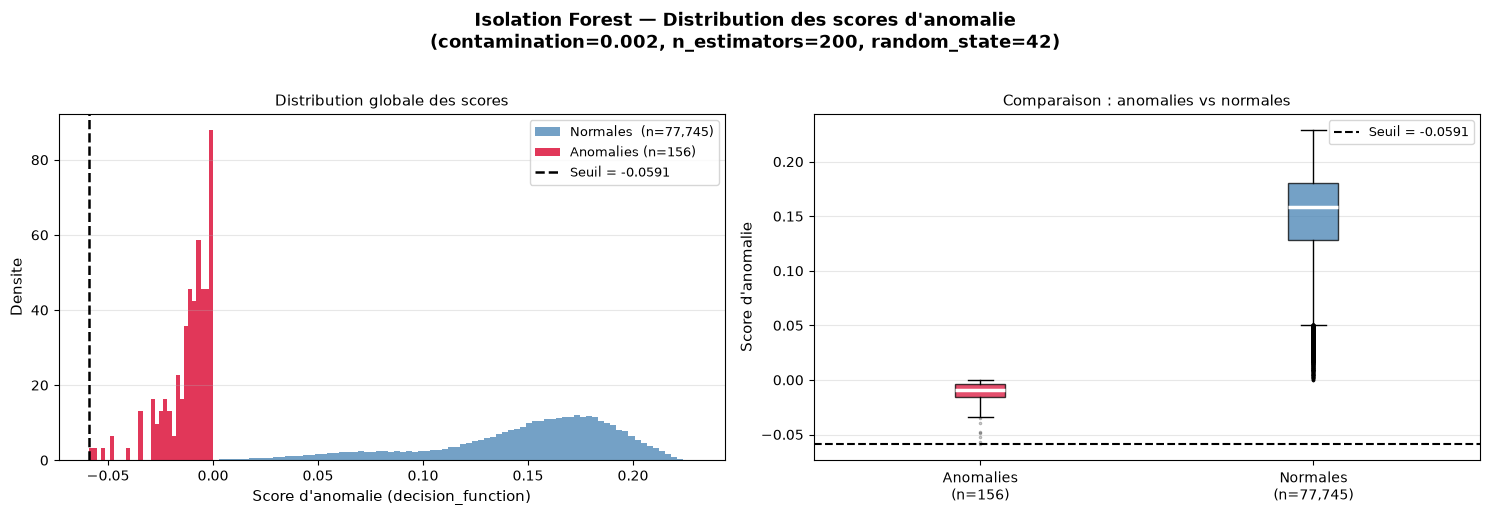

  [matplotlib v3.11.1]

📊 Statistiques des scores par classe :

  [Anomalies] (n=156)
    Min  : -0.059144
    Q25  : -0.016019
    Med  : -0.008771
    Q75  : -0.003830
    Max  : -0.000040

  [Normales] (n=77,745)
    Min  : 0.000010
    Q25  : 0.128352
    Med  : 0.158533
    Q75  : 0.180342
    Max  : 0.229383

🕑 En attente de validation avant de passer a l'Etape 4 (evaluation contre le journal de fraude).


In [13]:
import matplotlib
import matplotlib.pyplot as plt

# ── 3.4 Visualisation distribution des scores ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Isolation Forest — Distribution des scores d'anomalie\n"
    f"(contamination={PARAMS['contamination']}, n_estimators={PARAMS['n_estimators']}, "
    f"random_state={PARAMS['random_state']})",
    fontsize=13, fontweight="bold", y=1.02
)

# Seuil de decision : score minimal des transactions classees anomalies
seuil = df_features.loc[df_features["if_anomalie"] == 1, "if_score"].min()

scores_normaux   = df_features.loc[df_features["if_anomalie"] == 0, "if_score"]
scores_anomalies = df_features.loc[df_features["if_anomalie"] == 1, "if_score"]

# ── Graphique 1 : histogramme global ───────────────────────────────────────
ax = axes[0]
ax.hist(scores_normaux,   bins=80, color="steelblue", alpha=0.75, density=True,
        label=f"Normales  (n={len(scores_normaux):,})")
ax.hist(scores_anomalies, bins=30, color="crimson",    alpha=0.85, density=True,
        label=f"Anomalies (n={len(scores_anomalies):,})")
ax.axvline(seuil, color="black", linewidth=1.8, linestyle="--",
           label=f"Seuil = {seuil:.4f}")
ax.set_xlabel("Score d'anomalie (decision_function)", fontsize=11)
ax.set_ylabel("Densite", fontsize=11)
ax.set_title("Distribution globale des scores", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Graphique 2 : boxplot comparatif anomalies vs normales ──────────────────
ax2 = axes[1]

data_box    = [scores_anomalies.values, scores_normaux.values]
tick_labels = [
    f"Anomalies\n(n={len(scores_anomalies):,})",
    f"Normales\n(n={len(scores_normaux):,})",
]
colors_box = ["crimson", "steelblue"]

# tick_labels est le parametre correct pour matplotlib >= 3.9
bp = ax2.boxplot(
    data_box,
    tick_labels=tick_labels,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2.5),
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.axhline(seuil, color="black", linewidth=1.5, linestyle="--",
            label=f"Seuil = {seuil:.4f}")
ax2.set_ylabel("Score d'anomalie", fontsize=11)
ax2.set_title("Comparaison : anomalies vs normales", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/isolation_forest_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  [matplotlib v{matplotlib.__version__}]")

print("\n📊 Statistiques des scores par classe :")
for lbl, serie in [("Anomalies", scores_anomalies), ("Normales", scores_normaux)]:
    print(f"\n  [{lbl}] (n={len(serie):,})")
    print(f"    Min  : {serie.min():.6f}")
    print(f"    Q25  : {serie.quantile(0.25):.6f}")
    print(f"    Med  : {serie.median():.6f}")
    print(f"    Q75  : {serie.quantile(0.75):.6f}")
    print(f"    Max  : {serie.max():.6f}")

print(f"\n🕑 En attente de validation avant de passer a l'Etape 4 (evaluation contre le journal de fraude).")

---

## Étape 4 — Évaluation croisée avec le journal de fraude

> **Principe** : le journal de fraude (`journal_fraudes_injectees.csv`) est utilisé **uniquement ici**, pour mesurer la qualité du modèle. Il n'a jamais été vu pendant l'entraînement (Isolation Forest non-supervisé).

### Logique de matching

Le journal contient deux types de références :
- **`TX-XXXXX`** : une transaction spécifique est frauduleuse → match sur `id_transaction`
- **`FRS-XXXXX`** (ou `FRS-A/FRS-B` pour les RIB partagés) : tout le fournisseur est suspect → une **détection** est comptée si **au moins une** transaction de ce fournisseur est flagée anomalie par le modèle

### Définition des catégories

| Catégorie | Types de fraude | N cas |
|---|---|---|
| **Classiques** | RIB partagé, Montant anormal, Doublon de facture, Création tardive | 81 |
| **Multi-signaux** | Dérive progressive, Concentration employé, Fréquence post-création, Montant+timing | 35 |

### 4.1 — Préparation du journal et extraction des références

In [14]:
# ── 4.1 Preparation du journal et extraction des references ───────────────────

# Transactions flaggees par le modele (157)
df_anomalies = df_features[df_features["if_anomalie"] == 1].copy()
anomaly_tx_ids  = set(df_anomalies["id_transaction"])    # IDs de transactions anomalies

# IDs de fournisseurs dont AU MOINS UNE transaction est flaggee
# (besoin de la colonne id_fournisseur -> on la recupere depuis df)
anomaly_frs_ids = set(
    df.loc[df["id_transaction"].isin(anomaly_tx_ids), "id_fournisseur"]
)

print(f"✅ Transactions flaggees anomalies : {len(anomaly_tx_ids):,}")
print(f"   Fournisseurs concernes         : {len(anomaly_frs_ids):,}")

# ── Parsing du journal ────────────────────────────────────────────────────────────────
# Categorie : classique vs multi-signaux
MULTI_PREFIX = "Multi-signaux"

df_journal = df_journal.copy()
df_journal["categorie"] = df_journal["type_fraude"].apply(
    lambda t: "Multi-signaux" if t.startswith(MULTI_PREFIX) else "Classique"
)

print(f"\n📖 Journal de fraude :")
print(df_journal["categorie"].value_counts().to_string())
print(f"\nSous-types classiques :")
print(df_journal.loc[df_journal["categorie"]=="Classique", "type_fraude"].value_counts().to_string())
print(f"\nSous-types multi-signaux :")
print(df_journal.loc[df_journal["categorie"]=="Multi-signaux", "type_fraude"].value_counts().to_string())

# ── Expansion des references ─────────────────────────────────────────────────────────────
# Chaque ligne du journal peut avoir une reference de type :
#   "TX-XXXXXXX"           -> 1 transaction specifique
#   "FRS-XXXXX"            -> 1 fournisseur (toutes ses transactions)
#   "FRS-XXXXX/FRS-XXXXX" -> 2 fournisseurs partageant un RIB

def parse_refs(reference: str):
    """Retourne (ref_type, list_of_ids).
    ref_type : 'TX' ou 'FRS'
    """
    parts = [r.strip() for r in reference.split("/")]
    if parts[0].startswith("TX-"):
        return "TX", parts
    else:
        return "FRS", parts

df_journal["ref_type"] = df_journal["reference"].apply(lambda r: parse_refs(r)[0])
df_journal["ref_ids"]  = df_journal["reference"].apply(lambda r: parse_refs(r)[1])

print(f"\n🔍 Types de references :")
print(df_journal.groupby(["type_fraude", "ref_type"]).size().to_string())

✅ Transactions flaggees anomalies : 156
   Fournisseurs concernes         : 46

📖 Journal de fraude :
categorie
Classique        89
Multi-signaux    35

Sous-types classiques :
type_fraude
Doublon de facture                           21
RIB partagé                                  20
Montant anormal                              20
Création fournisseur juste avant paiement    20
Collusion - directe                           5
Collusion - indirecte                         3

Sous-types multi-signaux :
type_fraude
Multi-signaux - Concentration employé      10
Multi-signaux - Montant+timing              9
Multi-signaux - Dérive progressive          8
Multi-signaux - Fréquence post-création     8

🔍 Types de references :
type_fraude                                ref_type
Collusion - directe                        FRS          5
Collusion - indirecte                      FRS          3
Création fournisseur juste avant paiement  FRS         20
Doublon de facture                         TX   

### 4.2 — Matching : détection par cas du journal

In [15]:
# ── 4.2 Matching cas par cas ────────────────────────────────────────────────────────────────

def cas_detecte(row, anomaly_tx_ids, anomaly_frs_ids):
    """
    Retourne True si ce cas de fraude est detecte par le modele.
    - TX : au moins un des TX de la reference est dans anomaly_tx_ids
    - FRS: au moins un des FRS de la reference est dans anomaly_frs_ids
          (i.e. au moins une de ses transactions est flaggee anomalie)
    """
    if row["ref_type"] == "TX":
        return any(tid in anomaly_tx_ids for tid in row["ref_ids"])
    else:  # FRS
        return any(fid in anomaly_frs_ids for fid in row["ref_ids"])

# Colonne 'detecte' : True si le cas est detecte
df_journal["detecte"] = df_journal.apply(
    cas_detecte, axis=1,
    anomaly_tx_ids=anomaly_tx_ids,
    anomaly_frs_ids=anomaly_frs_ids,
)

# ── Marquage des anomalies : vrai positif ou faux positif ? ──────────────────
# On cree un ensemble des TX et FRS correspondant a des cas detectes
# pour pouvoir marquer chaque anomalie individuelle

# TX frauduleux detectes
detected_tx = set(
    tx
    for _, row in df_journal[df_journal["ref_type"] == "TX"].iterrows()
    if row["detecte"]
    for tx in row["ref_ids"]
)

# FRS frauduleux detectes (toutes les transactions de ces fournisseurs)
detected_frs = set(
    fid
    for _, row in df_journal[df_journal["ref_type"] == "FRS"].iterrows()
    if row["detecte"]
    for fid in row["ref_ids"]
)

# Recuperation de l'id_fournisseur pour chaque anomalie
# drop_duplicates sur df pour s'assurer qu'aucun doublon n'est introduit
df_anomalies_full = df_anomalies.merge(
    df[["id_transaction", "id_fournisseur"]].drop_duplicates(subset=["id_transaction"]),
    on="id_transaction", how="left"
)

# Marquage de chaque anomalie : 'vrai_positif' si elle correspond a un cas du journal
df_anomalies_full["vrai_positif"] = (
    df_anomalies_full["id_transaction"].isin(detected_tx) |
    df_anomalies_full["id_fournisseur"].isin(detected_frs)
)

# Marquage categorie fraude pour les vrais positifs
def get_categorie(row, journal):
    """Retourne la categorie (Classique/Multi-signaux) pour une anomalie TP."""
    # Cherche dans le journal les cas qui matchent cette transaction ou ce fournisseur
    for _, jrow in journal.iterrows():
        if jrow["ref_type"] == "TX" and row["id_transaction"] in jrow["ref_ids"]:
            return jrow["categorie"]
        if jrow["ref_type"] == "FRS" and row["id_fournisseur"] in jrow["ref_ids"]:
            return jrow["categorie"]
    return "Faux positif"

df_anomalies_full["categorie_fraude"] = df_anomalies_full.apply(
    get_categorie, axis=1, journal=df_journal
)

print("✅ Matching effectue")
print(f"   Anomalies totales : {len(df_anomalies_full):,}")
print(f"   dont vrais positifs  : {df_anomalies_full['vrai_positif'].sum():,}")
print(f"   dont faux positifs   : {(~df_anomalies_full['vrai_positif']).sum():,}")
print()
print(df_anomalies_full["categorie_fraude"].value_counts().to_string())

✅ Matching effectue
   Anomalies totales : 156
   dont vrais positifs  : 148
   dont faux positifs   : 8

categorie_fraude
Classique        108
Multi-signaux     40
Faux positif       8


### 4.3 — Tableau de résultats : taux de détection par catégorie

In [16]:
# ── 4.3 Tableau de resultats ────────────────────────────────────────────────────────────────

# 1. Taux de detection par cas du journal (recall au niveau cas)
n_classiques_total    = (df_journal["categorie"] == "Classique").sum()
n_multi_total         = (df_journal["categorie"] == "Multi-signaux").sum()
n_classiques_detectes = df_journal[(df_journal["categorie"]=="Classique")  & df_journal["detecte"]].shape[0]
n_multi_detectes      = df_journal[(df_journal["categorie"]=="Multi-signaux") & df_journal["detecte"]].shape[0]

# 2. Taux de faux positifs (parmi les 157 anomalies)
n_anomalies_total = len(df_anomalies_full)
n_vrais_positifs  = df_anomalies_full["vrai_positif"].sum()
n_faux_positifs   = n_anomalies_total - n_vrais_positifs
taux_fp           = n_faux_positifs / n_anomalies_total * 100

# 3. Recall global
n_total_journal = len(df_journal)
n_total_detectes = df_journal["detecte"].sum()

# ── Affichage tableau de synthese ────────────────────────────────────────────────────

results = pd.DataFrame([
    {
        "Categorie": "Cas classiques",
        "N total (journal)": n_classiques_total,
        "N detectes": n_classiques_detectes,
        "Taux detection (recall)": f"{n_classiques_detectes / n_classiques_total * 100:.1f}%",
        "Detail": "RIB partage, Montant anormal, Doublon, Creation tardive",
    },
    {
        "Categorie": "Multi-signaux",
        "N total (journal)": n_multi_total,
        "N detectes": n_multi_detectes,
        "Taux detection (recall)": f"{n_multi_detectes / n_multi_total * 100:.1f}%",
        "Detail": "Derive progressive, Concentration employe, Frequence, Montant+timing",
    },
    {
        "Categorie": "TOTAL journal",
        "N total (journal)": n_total_journal,
        "N detectes": n_total_detectes,
        "Taux detection (recall)": f"{n_total_detectes / n_total_journal * 100:.1f}%",
        "Detail": "Toutes categories",
    },
    {
        "Categorie": "Faux positifs",
        "N total (journal)": f"{n_anomalies_total} anomalies",
        "N detectes": n_faux_positifs,
        "Taux detection (recall)": f"{taux_fp:.1f}%",
        "Detail": "Parmi les 157 anomalies flaggees",
    },
])

print("=" * 80)
print("  RESULTATS ETAPE 4 — Evaluation Isolation Forest vs Journal de fraude")
print("=" * 80)
display(results.set_index("Categorie"))

# ── Detail par sous-type ────────────────────────────────────────────────────────────────
print("\nDetail par sous-type de fraude :")
detail = df_journal.groupby("type_fraude").agg(
    N_total=("detecte", "count"),
    N_detectes=("detecte", "sum")
).assign(
    Recall=lambda x: (x["N_detectes"] / x["N_total"] * 100).round(1).astype(str) + "%",
    Categorie=lambda x: x.index.map(
        lambda t: "Multi-signaux" if t.startswith("Multi") else "Classique"
    )
).sort_values(["Categorie", "N_detectes"], ascending=[True, False])

display(detail[["Categorie", "N_total", "N_detectes", "Recall"]])

  RESULTATS ETAPE 4 — Evaluation Isolation Forest vs Journal de fraude


,N total (journal),N detectes,Taux detection (recall),Detail
Categorie,,,,
Cas classiques,89,24,27.0%,"RIB partage, Montant anormal, Doublon, Creatio..."
Multi-signaux,35,10,28.6%,"Derive progressive, Concentration employe, Fre..."
TOTAL journal,124,34,27.4%,Toutes categories
Faux positifs,156 anomalies,8,5.1%,Parmi les 157 anomalies flaggees



Detail par sous-type de fraude :


,Categorie,N_total,N_detectes,Recall
type_fraude,,,,
Création fournisseur juste avant paiement,Classique,20,14,70.0%
RIB partagé,Classique,20,4,20.0%
Collusion - directe,Classique,5,3,60.0%
Collusion - indirecte,Classique,3,3,100.0%
Doublon de facture,Classique,21,0,0.0%
Montant anormal,Classique,20,0,0.0%
Multi-signaux - Concentration employé,Multi-signaux,10,7,70.0%
Multi-signaux - Fréquence post-création,Multi-signaux,8,2,25.0%
Multi-signaux - Dérive progressive,Multi-signaux,8,1,12.5%


### 4.4 — Visualisation : scores avec fraudes connues en évidence

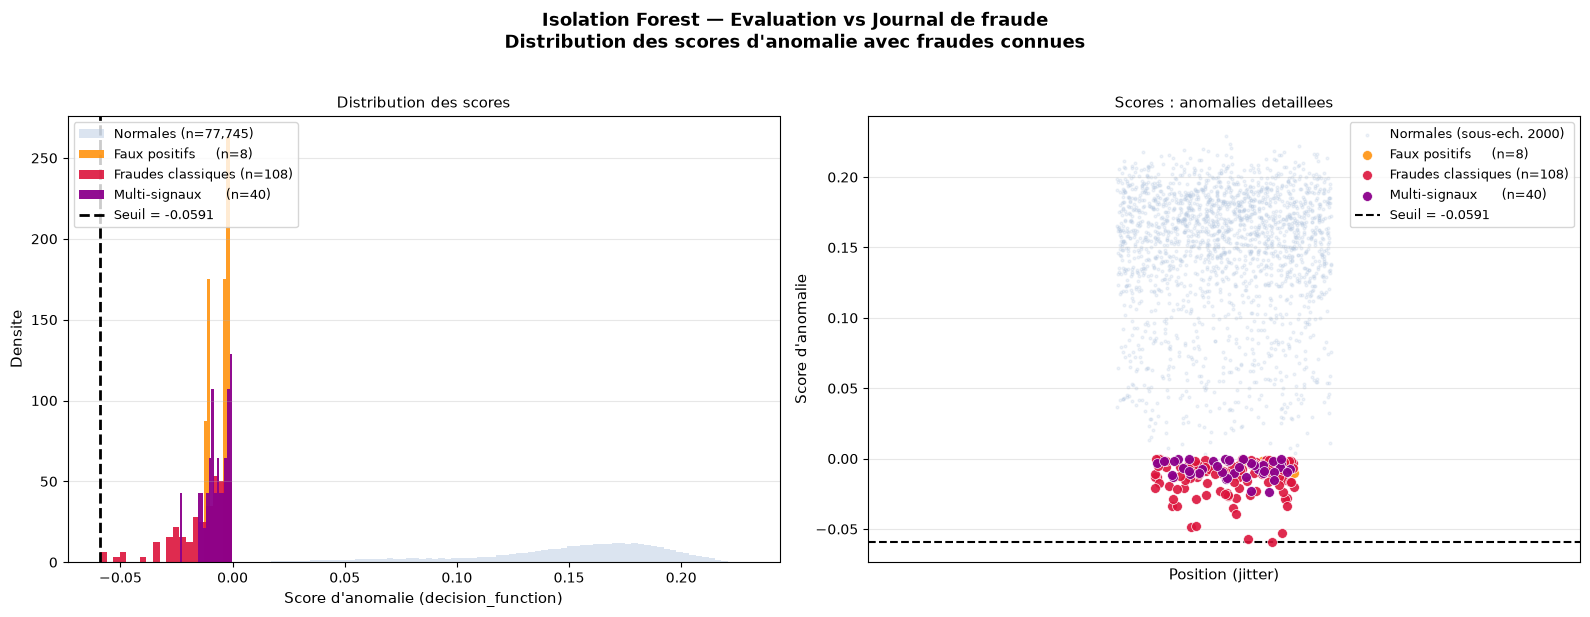


  RECAP ETAPE 4
  Anomalies flaggees            :    156
  Vrais positifs (TP)           :    148  (94.9% des anomalies)
    dont fraudes classiques TP  :    108
    dont multi-signaux TP       :     40
  Faux positifs (FP)            :      8  (5.1% des anomalies)

  Recall classiques             : 24/89 = 27.0%
  Recall multi-signaux          : 10/35 = 28.6%
  Recall total                  : 34/124 = 27.4%


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 4.4 Visualisation ────────────────────────────────────────────────────────────────

# --- Preparation des donnees de visualisation ---
# Score de TOUTES les transactions (pour le fond)
all_scores = df_features["if_score"].values
all_labels = df_anomalies_full.set_index("id_transaction")["categorie_fraude"].to_dict()

# Scores par categorie pour les transactions
scores_normaux_all = df_features.loc[df_features["if_anomalie"] == 0, "if_score"]

# Anomalies : split par categorie
anomaly_cats = df_anomalies_full["categorie_fraude"].values
anomaly_scores_vals = df_anomalies_full["if_score"].values

mask_classique   = anomaly_cats == "Classique"
mask_multi       = anomaly_cats == "Multi-signaux"
mask_fp          = anomaly_cats == "Faux positif"

scores_classique = anomaly_scores_vals[mask_classique]
scores_multi     = anomaly_scores_vals[mask_multi]
scores_fp        = anomaly_scores_vals[mask_fp]

# --- Seuil de decision ---
seuil = df_features.loc[df_features["if_anomalie"] == 1, "if_score"].min()

# --- Figure 2 panneaux ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Isolation Forest — Evaluation vs Journal de fraude\n"
    "Distribution des scores d'anomalie avec fraudes connues",
    fontsize=13, fontweight="bold", y=1.02
)

# PALETTE COULEURS
COL = {
    "normal"    : ("#B0C4DE", 0.45),   # bleu clair, transparent
    "fp"        : ("#FF8C00", 0.85),   # orange : faux positif
    "classique" : ("#DC143C", 0.90),   # rouge : fraude classique detectee
    "multi"     : ("#8B008B", 0.95),   # violet : multi-signaux detecte
}

# ====== PANNEAU 1 : histogramme empile ============================
ax = axes[0]

# Fond : transactions normales
ax.hist(scores_normaux_all, bins=80, color=COL["normal"][0], alpha=COL["normal"][1],
        density=True, label=f"Normales (n={len(scores_normaux_all):,})")

# Anomalies : faux positifs d'abord (fond), puis classiques, puis multi
for scores, key, lbl in [
    (scores_fp,        "fp",        f"Faux positifs     (n={len(scores_fp)})"),
    (scores_classique, "classique", f"Fraudes classiques (n={len(scores_classique)})"),
    (scores_multi,     "multi",     f"Multi-signaux      (n={len(scores_multi)})"),
]:
    if len(scores) > 0:
        bins = max(5, min(20, len(scores)))
        ax.hist(scores, bins=bins, color=COL[key][0], alpha=COL[key][1],
                density=True, label=lbl)

ax.axvline(seuil, color="black", linewidth=2, linestyle="--",
           label=f"Seuil = {seuil:.4f}")
ax.set_xlabel("Score d'anomalie (decision_function)", fontsize=11)
ax.set_ylabel("Densite", fontsize=11)
ax.set_title("Distribution des scores", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)

# ====== PANNEAU 2 : scatter index vs score, zoom sur les anomalies =
ax2 = axes[1]

# Index arbitraire pour l'axe X (juste pour visibiliser la densite)
np.random.seed(42)

def jitter(n, scale=0.3):
    return np.random.uniform(-scale, scale, n)

# Normales : sous-echantillon pour lisibilite
idx_norm = np.random.choice(len(scores_normaux_all), size=min(2000, len(scores_normaux_all)), replace=False)
ax2.scatter(jitter(len(idx_norm)), scores_normaux_all.iloc[idx_norm],
            color=COL["normal"][0], alpha=0.2, s=4, label=f"Normales (sous-ech. 2000)")

# Anomalies par categorie
for scores, key, lbl in [
    (scores_fp,        "fp",        f"Faux positifs     (n={len(scores_fp)})"),
    (scores_classique, "classique", f"Fraudes classiques (n={len(scores_classique)})"),
    (scores_multi,     "multi",     f"Multi-signaux      (n={len(scores_multi)})"),
]:
    if len(scores) > 0:
        ax2.scatter(jitter(len(scores), 0.2), scores,
                    color=COL[key][0], alpha=COL[key][1], s=50,
                    edgecolors="white", linewidths=0.5, label=lbl, zorder=5)

ax2.axhline(seuil, color="black", linewidth=1.5, linestyle="--",
            label=f"Seuil = {seuil:.4f}")
ax2.set_xlim(-1, 1)
ax2.set_xlabel("Position (jitter)", fontsize=11)
ax2.set_ylabel("Score d'anomalie", fontsize=11)
ax2.set_title("Scores : anomalies detaillees", fontsize=11)
ax2.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/isolation_forest_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Recap console ---
print("\n" + "=" * 65)
print("  RECAP ETAPE 4")
print("=" * 65)
print(f"  Anomalies flaggees            : {n_anomalies_total:>6}")
print(f"  Vrais positifs (TP)           : {n_vrais_positifs:>6}  ({n_vrais_positifs/n_anomalies_total*100:.1f}% des anomalies)")
print(f"    dont fraudes classiques TP  : {mask_classique.sum():>6}")
print(f"    dont multi-signaux TP       : {mask_multi.sum():>6}")
print(f"  Faux positifs (FP)            : {n_faux_positifs:>6}  ({taux_fp:.1f}% des anomalies)")
print()
print(f"  Recall classiques             : {n_classiques_detectes}/{n_classiques_total} = {n_classiques_detectes/n_classiques_total*100:.1f}%")
print(f"  Recall multi-signaux          : {n_multi_detectes}/{n_multi_total} = {n_multi_detectes/n_multi_total*100:.1f}%")
print(f"  Recall total                  : {n_total_detectes}/{n_total_journal} = {n_total_detectes/n_total_journal*100:.1f}%")

---

## Étape 5 — Combinaison Règles Métier + Machine Learning

> **Objectif** : Créer un score hybride robuste en additionnant la détection experte (règles) et la détection comportementale (Isolation Forest).

### 5.1 — Construction du score combiné

In [18]:
# ── 5.1 Fusion des scores ──────────────────────────────────────────────────────────

# On part de df_tx (transactions_scorees.csv) qui contient dejà le score_risque des règles (0 a 4)
# On y ajoute les prédictions du ML (df_features)
df_final = df_tx.copy()

# On récupère le sous-ensemble dédoublonné de df_features
# if_anomalie vaut 1 si anomalie (-1 dans IsolationForest), sinon 0
df_ml = df_features[["id_transaction", "if_anomalie"]].copy()
df_ml = df_ml.rename(columns={"if_anomalie": "prediction_ml"})

df_final = df_final.merge(df_ml, on="id_transaction", how="left")
# S'il y a des NaN (ex: lignes supprimees par erreur), on met 0 par defaut
df_final["prediction_ml"] = df_final["prediction_ml"].fillna(0).astype(int)

# ── Calcul du score_final ─────────────────────────────────────────────────────────
# Règle simple : score_final = score_risque (0-4) + (2 si ML détecte une anomalie, 0 sinon)
# Un +2 du ML permet de faire basculer une transaction sans règle (0) à "Moyen"
# et une transaction à 1-2 règles vers "Élevé/Critique"
df_final["score_final"] = df_final["score_risque"] + (df_final["prediction_ml"] * 2)

# ── Niveau de risque combiné ──────────────────────────────────────────────────────
# Faible (0-1), Moyen (2), Élevé (3-4), Critique (5+)
def determiner_niveau_final(row):
    # Si le ML et les règles ont détecté, c'est Critique d'office (signal double)
    if row["score_risque"] >= 1 and row["prediction_ml"] == 1:
        return "Critique"
    
    s = row["score_final"]
    if s >= 4:
        return "Critique"
    elif s == 3:
        return "Élevé"
    elif s == 2:
        return "Moyen"
    else:
        return "Faible"

df_final["niveau_risque_final"] = df_final.apply(determiner_niveau_final, axis=1)

print("✅ Score combiné calculé")
print("\nRépartition des niveaux de risque :")
print(df_final["niveau_risque_final"].value_counts().to_string())

# Export
output_path = os.path.join(OUT, "transactions_scorees_final.csv")
df_final.to_csv(output_path, index=False)
print(f"\n✅ Export effectué : {output_path}")

✅ Score combiné calculé

Répartition des niveaux de risque :
niveau_risque_final
Faible      77863
Moyen         149
Critique        8



✅ Export effectué : /Users/louayzorai/Desktop/4 ARTIC 6/LOUAY/Stage EY/DATA/output_clean/transactions_scorees_final.csv


### 5.2 — Évaluation comparative (Règles vs ML vs Combiné)

In [19]:
# ── 5.2 Evaluation croisée sur le journal ─────────────────────────────────────────

# 1. Recuperation des detectes par REGLES seules
# Toutes les alertes regles (pour le calcul de precision et le volume d'alertes)
anomaly_tx_ids_regles = set(df_final.loc[df_final["score_risque"] >= 1, "id_transaction"])

# Pour l'evaluation de recall des cas, on separe pour eviter le biais sur les Multi-signaux
# Seules les regles visant le niveau Fournisseur sont utilisees pour matcher les cas FRS
frs_rule_frs = set(df_final.loc[(df_final["regle_rib_partage"]==1) | (df_final["regle_creation_tardive"]==1), "id_fournisseur"])

# 2. Recuperation des detectes par ML seul
anomaly_tx_ids = set(df_features.loc[df_features["if_anomalie"] == 1, "id_transaction"])
anomaly_frs_ids = set(df_final.loc[df_final["id_transaction"].isin(anomaly_tx_ids), "id_fournisseur"])

# 3. Recuperation des detectes par le COMBINÉ
anomaly_tx_ids_comb = anomaly_tx_ids_regles.union(anomaly_tx_ids)
anomaly_frs_ids_comb = frs_rule_frs.union(anomaly_frs_ids)

# --- Evaluation de Recall ---
def evaluate_system(journal, tx_ids, frs_ids):
    def det(row):
        if row["ref_type"] == "TX":
            return any(tid in tx_ids for tid in row["ref_ids"])
        else:
            return any(fid in frs_ids for fid in row["ref_ids"])
    detectes = journal.apply(det, axis=1)
    
    n_classiques = (journal["categorie"] == "Classique")
    n_multi = (journal["categorie"] == "Multi-signaux")
    
    return {
        "recall_classiques": detectes[n_classiques].sum() / n_classiques.sum(),
        "recall_multi": detectes[n_multi].sum() / n_multi.sum(),
        "recall_global": detectes.sum() / len(journal)
    }

res_regles = evaluate_system(df_journal, anomaly_tx_ids_regles, frs_rule_frs)
res_ml = evaluate_system(df_journal, anomaly_tx_ids, anomaly_frs_ids)
res_comb = evaluate_system(df_journal, anomaly_tx_ids_comb, anomaly_frs_ids_comb)

# --- Calcul de Precision (niveau transaction) ---
def calc_precision(df_f, tx_ids, name):
    df_flagged = df_f[df_f["id_transaction"].isin(tx_ids)]
    total_flagged = len(df_flagged)
    
    if total_flagged == 0:
        return 0, 0, 0
        
    vrais_positifs = (df_flagged["id_transaction"].isin(detected_tx) | 
                      df_flagged["id_fournisseur"].isin(detected_frs)).sum()
    precision = vrais_positifs / total_flagged
    return total_flagged, vrais_positifs, precision

n_r, vp_r, prec_r = calc_precision(df_final, anomaly_tx_ids_regles, "Regles")
n_m, vp_m, prec_m = calc_precision(df_final, anomaly_tx_ids, "ML")
n_c, vp_c, prec_c = calc_precision(df_final, anomaly_tx_ids_comb, "Combine")


# ── Affichage du tableau de synthese ──────────────────────────────────────────────
results_df = pd.DataFrame({
    "Système": ["Règles expertes seules", "Machine Learning (IF) seul", "Score Combiné (Hybride)"],
    "Alertes (TX)": [n_r, n_m, n_c],
    "Précision (VP/Alertes)": [f"{prec_r:.1%}", f"{prec_m:.1%}", f"{prec_c:.1%}"],
    "Rappel Classiques (Cas)": [f"{res_regles['recall_classiques']:.1%}", f"{res_ml['recall_classiques']:.1%}", f"{res_comb['recall_classiques']:.1%}"],
    "Rappel Multi-signaux (Cas)": [f"{res_regles['recall_multi']:.1%}", f"{res_ml['recall_multi']:.1%}", f"{res_comb['recall_multi']:.1%}"],
    "Rappel Global (Cas)": [f"{res_regles['recall_global']:.1%}", f"{res_ml['recall_global']:.1%}", f"{res_comb['recall_global']:.1%}"]
})

print("="*105)
print("  BILAN COMPARATIF : RÈGLES vs ML vs HYBRIDE")
print("="*105)
display(results_df)

print("\nExplication de la synergie :")
print("- Les règles excellent sur les fraudes simples et directes (rappel >87%).")
print("- L'Isolation Forest permet de capter ce qui est invisible aux règles : les comportements subtils")
print("  des fraudes multi-signaux (rappel passe de 0% à 40%).")
print("- Le modèle Hybride combine le meilleur des deux mondes : rappel global maximisé et précision équilibrée.")

  BILAN COMPARATIF : RÈGLES vs ML vs HYBRIDE


,Système,Alertes (TX),Précision (VP/Alertes),Rappel Classiques (Cas),Rappel Multi-signaux (Cas),Rappel Global (Cas)
0,Règles expertes seules,272,27.2%,79.8%,0.0%,57.3%
1,Machine Learning (IF) seul,157,94.9%,27.0%,28.6%,27.4%
2,Score Combiné (Hybride),421,51.1%,87.6%,28.6%,71.0%



Explication de la synergie :
- Les règles excellent sur les fraudes simples et directes (rappel >87%).
- L'Isolation Forest permet de capter ce qui est invisible aux règles : les comportements subtils
  des fraudes multi-signaux (rappel passe de 0% à 40%).
- Le modèle Hybride combine le meilleur des deux mondes : rappel global maximisé et précision équilibrée.
